# Final Test Comparison: 2.5D V2 vs 3D V2

This notebook runs the held-out `test` split and compares four methods on the same cross-subject pairs:

- `2.5D axial`
- `2.5D mean_fused`
- `2.5D smoothed_0.75`
- `3D V2`

The 2.5D fusion is the same deterministic postprocess used in the earlier fusion notebook.

In [1]:
import os
import sys
import json
import time
import random
import importlib.util
from pathlib import Path

os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display, Image

SEED = 17
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except TypeError:
    torch.use_deterministic_algorithms(True)

AVAILABLE_DEVICE_NAMES = ['cpu']
if torch.cuda.is_available():
    AVAILABLE_DEVICE_NAMES.append('cuda')
REQUESTED_DEVICE_NAMES = [name for name in ['cpu', 'cuda'] if name in AVAILABLE_DEVICE_NAMES]
device = torch.device(REQUESTED_DEVICE_NAMES[0])
BASE_DIR = Path('.').resolve()
PYC_DIR = BASE_DIR / '__pycache__'
DATA_ROOT = '../Data/Tuco'

PAIR_SEED = SEED + 29
PAIR_LIMIT = None
MAX_TEST_SUBJECTS = None

WINDOW_RADIUS = 3
SEG_LABELS = [2, 3, 4, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 26, 28]
ORIENTATIONS = [
    {'axis': 0, 'name': 'axial', 'target_hw': (112, 96)},
    {'axis': 1, 'name': 'coronal', 'target_hw': (96, 96)},
    {'axis': 2, 'name': 'sagittal', 'target_hw': (96, 112)},
]
TARGET_VOL_SHAPE_3D = (96, 112, 96)
SMOOTH_SIGMA = 0.75
EVAL_BATCH_SIZE_2P5D = 16

MODEL_2P5D_PATH = './trained_weights/2p5d_dense_pt_v2_best.pth'
MODEL_3D_PATH = './trained_weights/3d_dense_v2_best.pth'
OUTPUT_ROOT = Path('./artifacts/results/compare_2p5d_fusion_3d_v2_test')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print('Available devices:', AVAILABLE_DEVICE_NAMES)
print('Requested devices:', REQUESTED_DEVICE_NAMES)
print('2.5D weights:', MODEL_2P5D_PATH)
print('3D weights:', MODEL_3D_PATH)
print('Output root:', OUTPUT_ROOT)



Available devices: ['cpu', 'cuda']
Requested devices: ['cpu', 'cuda']
2.5D weights: ./trained_weights/2p5d_dense_pt_v2_best.pth
3D weights: ./trained_weights/3d_dense_v2_best.pth
Output root: artifacts/results/compare_2p5d_fusion_3d_v2_test


In [2]:
def _load_pyc(name):
    pyc = next(PYC_DIR.glob(f'{name}.cpython-*.pyc'), None)
    if pyc is None:
        raise FileNotFoundError(f'Could not find compiled module for {name} in {PYC_DIR}')
    spec = importlib.util.spec_from_file_location(name, pyc)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    sys.modules[name] = mod


_load_pyc('tuco_dataset')
from tuco_dataset import TucoDataset
from torch.utils.data import Subset


def normalize_volume_contract(volume):
    arr = volume.astype(np.float32)
    arr_min = float(arr.min())
    arr_max = float(arr.max())
    if arr_max <= arr_min:
        return np.zeros_like(arr, dtype=np.float32)
    if arr_min >= -1.001 and arr_max <= 1.001:
        if arr_min >= -1e-4 and arr_max <= 1.0001:
            return (2.0 * arr - 1.0).astype(np.float32)
        return arr
    return (2.0 * (arr - arr_min) / (arr_max - arr_min) - 1.0).astype(np.float32)


def load_split(split, max_n=None):
    ds = TucoDataset(DATA_ROOT, split=split)
    if max_n is not None:
        ds = Subset(ds, range(min(max_n, len(ds))))
    return ds


def get_sample_parts(ds, idx):
    sample = ds[idx]
    moving = normalize_volume_contract(sample['moving'].squeeze(0).numpy().astype(np.float32))
    fixed = normalize_volume_contract(sample['fixed'].squeeze(0).numpy().astype(np.float32))
    moving_seg = sample['moving_seg'].squeeze(0).numpy().astype(np.int16)
    fixed_seg = sample['fixed_seg'].squeeze(0).numpy().astype(np.int16)
    return moving, fixed, moving_seg, fixed_seg


def build_eval_pairs(n_subj, max_pairs=None, seed=PAIR_SEED):
    if n_subj < 2:
        return []
    rng = np.random.default_rng(seed)
    order = rng.permutation(n_subj)
    pairs = []
    for idx in range(0, len(order) - 1, 2):
        pairs.append((int(order[idx]), int(order[idx + 1])))
        if max_pairs is not None and len(pairs) >= max_pairs:
            break
    return pairs


test_ds = load_split('test', MAX_TEST_SUBJECTS)
test_pairs = build_eval_pairs(len(test_ds), max_pairs=PAIR_LIMIT, seed=PAIR_SEED)

print('Test subjects:', len(test_ds))
print('Test pairs:', test_pairs)


Found 18 volume pairs for split 'test'
Test subjects: 18
Test pairs: [(2, 17), (1, 12), (6, 0), (16, 4), (14, 8), (5, 9), (13, 11), (7, 10), (15, 3)]


In [3]:
def extract_slice(volume, axis, z):
    if axis == 0:
        return volume[z]
    if axis == 1:
        return volume[:, z, :]
    return volume[:, :, z]


def extract_stack(volume, axis, z, window_radius=WINDOW_RADIUS):
    wr = window_radius
    if axis == 0:
        return volume[z - wr:z + wr + 1]
    if axis == 1:
        return volume[:, z - wr:z + wr + 1, :].transpose(1, 0, 2)
    return volume[:, :, z - wr:z + wr + 1].transpose(2, 0, 1)


def resize_slice(slice_2d, target_hw, is_seg=False):
    target_h, target_w = target_hw
    interp = cv2.INTER_NEAREST if is_seg else cv2.INTER_LINEAR
    return cv2.resize(slice_2d, (target_w, target_h), interpolation=interp)


def resize_stack(stack, target_hw):
    resized = [resize_slice(stack[i], target_hw, is_seg=False) for i in range(stack.shape[0])]
    return np.ascontiguousarray(np.stack(resized).astype(np.float32))


def spatial_transform_2d(src, flow, mode='bilinear'):
    b, c, h, w = src.shape
    yy, xx = torch.meshgrid(
        torch.arange(h, device=src.device),
        torch.arange(w, device=src.device),
        indexing='ij'
    )
    base = torch.stack((xx, yy), dim=0).float().unsqueeze(0).expand(b, -1, -1, -1)
    new_locs = base + flow
    shape = torch.tensor([w - 1, h - 1], device=src.device).float().view(1, 2, 1, 1)
    new_locs = (new_locs / shape) * 2.0 - 1.0
    new_locs = new_locs.permute(0, 2, 3, 1)
    return F.grid_sample(src, new_locs, align_corners=True, mode=mode, padding_mode='border')


def seg_to_onehot_2d(seg, labels=SEG_LABELS):
    return torch.stack([(seg == lbl) for lbl in labels], dim=1).float().to(seg.device)


def onehot_to_seg_numpy(seg_oh, labels=SEG_LABELS, threshold=0.5):
    seg_np = seg_oh.detach().cpu().numpy()
    out = np.zeros((seg_np.shape[0], seg_np.shape[2], seg_np.shape[3]), dtype=np.int16)
    for li, lbl in enumerate(labels):
        out[seg_np[:, li] > threshold] = lbl
    return out


class Vxm2p5dDenseCoreV2(nn.Module):
    def __init__(self, n_stack=2 * WINDOW_RADIUS + 1, enc_feats=(16, 32, 32, 32), final_feats=(32, 16), flow_scale=0.1):
        super().__init__()
        self.enc_blocks = nn.ModuleList()
        self.down_blocks = nn.ModuleList()
        in_ch = n_stack * 2
        for nf in enc_feats:
            self.enc_blocks.append(nn.Sequential(
                nn.Conv2d(in_ch, nf, 3, padding=1, bias=False),
                nn.BatchNorm2d(nf),
                nn.LeakyReLU(0.1),
            ))
            self.down_blocks.append(nn.Sequential(
                nn.Conv2d(nf, nf, 3, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(nf),
                nn.LeakyReLU(0.1),
            ))
            in_ch = nf
        self.bottleneck = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
        )
        self.up_blocks = nn.ModuleList()
        self.dec_blocks = nn.ModuleList()
        in_ch = 32
        for skip_ch in reversed(enc_feats):
            self.up_blocks.append(nn.Upsample(scale_factor=2, mode='nearest'))
            self.dec_blocks.append(nn.Sequential(
                nn.Conv2d(in_ch + skip_ch, skip_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(skip_ch),
                nn.LeakyReLU(0.1),
            ))
            in_ch = skip_ch
        self.final_conv0 = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
        )
        self.final_conv1 = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1),
        )
        self.flow_unscaled = nn.Conv2d(16, 2, 3, padding=1)
        nn.init.zeros_(self.flow_unscaled.weight)
        nn.init.zeros_(self.flow_unscaled.bias)
        self.flow_scale = nn.Conv2d(2, 2, 1, bias=False)
        self.flow_scale.weight.data.zero_()
        self.flow_scale.weight.data[0, 0, 0, 0] = flow_scale
        self.flow_scale.weight.data[1, 1, 0, 0] = flow_scale
        self.flow_scale.weight.requires_grad = False

    def forward(self, moving_stack, fixed_stack):
        x = torch.cat([moving_stack, fixed_stack], dim=1)
        skips = []
        for enc, ds in zip(self.enc_blocks, self.down_blocks):
            x = enc(x)
            skips.append(x)
            x = ds(x)
        x = self.bottleneck(x)
        for up, dec, skip in zip(self.up_blocks, self.dec_blocks, reversed(skips)):
            x = up(x)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)
        x = self.final_conv0(x)
        x = self.final_conv1(x)
        return self.flow_scale(self.flow_unscaled(x))


@torch.no_grad()
def infer_volume_orientation_2p5d(model, moving_vol, fixed_vol, moving_seg, fixed_seg, orient_cfg, runtime_device, batch_size=EVAL_BATCH_SIZE_2P5D):
    axis = orient_cfg['axis']
    target_hw = orient_cfg['target_hw']
    depth = min(moving_vol.shape[axis], fixed_vol.shape[axis], moving_seg.shape[axis], fixed_seg.shape[axis])
    slice_indices = list(range(WINDOW_RADIUS, depth - WINDOW_RADIUS))
    flow_slices = []
    moving_center_slices = []
    fixed_center_slices = []
    warped_center_slices = []
    moving_seg_slices = []
    fixed_seg_slices = []
    warped_seg_slices = []
    batch_times_ms = []

    if runtime_device.type == 'cuda':
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(runtime_device)

    for start in range(0, len(slice_indices), batch_size):
        batch_indices = slice_indices[start:start + batch_size]
        moving_stack_batch = []
        fixed_stack_batch = []
        moving_center_batch = []
        fixed_center_batch = []
        moving_seg_batch = []
        fixed_seg_batch = []

        for z in batch_indices:
            moving_stack_batch.append(resize_stack(extract_stack(moving_vol, axis, z), target_hw))
            fixed_stack_batch.append(resize_stack(extract_stack(fixed_vol, axis, z), target_hw))
            moving_center_batch.append(resize_slice(extract_slice(moving_vol, axis, z), target_hw, is_seg=False))
            fixed_center_batch.append(resize_slice(extract_slice(fixed_vol, axis, z), target_hw, is_seg=False))
            moving_seg_batch.append(resize_slice(extract_slice(moving_seg, axis, z), target_hw, is_seg=True).astype(np.int64))
            fixed_seg_batch.append(resize_slice(extract_slice(fixed_seg, axis, z), target_hw, is_seg=True).astype(np.int64))

        moving_t = torch.from_numpy(np.stack(moving_stack_batch).astype(np.float32)).to(runtime_device)
        fixed_t = torch.from_numpy(np.stack(fixed_stack_batch).astype(np.float32)).to(runtime_device)
        moving_center_t = torch.from_numpy(np.stack(moving_center_batch)[:, None].astype(np.float32)).to(runtime_device)
        fixed_center_t = torch.from_numpy(np.stack(fixed_center_batch)[:, None].astype(np.float32)).to(runtime_device)
        moving_seg_t = torch.from_numpy(np.stack(moving_seg_batch).astype(np.int64)).to(runtime_device)
        fixed_seg_t = torch.from_numpy(np.stack(fixed_seg_batch).astype(np.int64)).to(runtime_device)

        if runtime_device.type == 'cuda':
            torch.cuda.synchronize(runtime_device)
        t0 = time.perf_counter()
        flow = model(moving_t, fixed_t)
        warped_center = spatial_transform_2d(moving_center_t, flow)
        warped_seg_oh = spatial_transform_2d(seg_to_onehot_2d(moving_seg_t), flow)
        if runtime_device.type == 'cuda':
            torch.cuda.synchronize(runtime_device)
        batch_times_ms.append((time.perf_counter() - t0) * 1000.0)

        flow_slices.append(flow.cpu().numpy())
        moving_center_slices.append(moving_center_t[:, 0].cpu().numpy())
        fixed_center_slices.append(fixed_center_t[:, 0].cpu().numpy())
        warped_center_slices.append(warped_center[:, 0].cpu().numpy())
        moving_seg_slices.append(moving_seg_t.cpu().numpy())
        fixed_seg_slices.append(fixed_seg_t.cpu().numpy())
        warped_seg_slices.append(onehot_to_seg_numpy(warped_seg_oh))

    moving_stack = np.concatenate(moving_center_slices, axis=0)
    fixed_stack = np.concatenate(fixed_center_slices, axis=0)
    warped_stack = np.concatenate(warped_center_slices, axis=0)
    moving_seg_stack = np.concatenate(moving_seg_slices, axis=0)
    fixed_seg_stack = np.concatenate(fixed_seg_slices, axis=0)
    warped_seg_stack = np.concatenate(warped_seg_slices, axis=0)
    flow_stack = np.concatenate(flow_slices, axis=0)
    peak_memory_mb = None
    if runtime_device.type == 'cuda':
        peak_memory_mb = float(torch.cuda.max_memory_allocated(runtime_device) / (1024 ** 2))

    return {
        'moving_stack': moving_stack,
        'fixed_stack': fixed_stack,
        'warped_stack': warped_stack,
        'moving_seg_stack': moving_seg_stack,
        'fixed_seg_stack': fixed_seg_stack,
        'warped_seg_stack': warped_seg_stack,
        'flow_stack': flow_stack,
        'summary': {
            'orientation': orient_cfg['name'],
            'axis': int(axis),
            'slice_count': int(len(slice_indices)),
            'inference_time_ms': float(np.sum(batch_times_ms)),
            'mean_batch_time_ms': float(np.mean(batch_times_ms)),
            'peak_memory_mb': peak_memory_mb,
        },
    }



In [4]:
def compute_dice_per_label(seg_a, seg_b, labels=SEG_LABELS):
    scores = []
    for lbl in labels:
        a = (seg_a == lbl).astype(np.float32)
        b = (seg_b == lbl).astype(np.float32)
        inter = float((a * b).sum())
        union = float(a.sum() + b.sum())
        scores.append(1.0 if union == 0.0 else 2.0 * inter / union)
    return np.array(scores, dtype=np.float32)


def mutual_information_np(a, b, bins=64, clip_range=(-1.0, 1.0)):
    hist_2d, _, _ = np.histogram2d(a.ravel(), b.ravel(), bins=bins, range=[clip_range, clip_range])
    pxy = hist_2d / np.maximum(hist_2d.sum(), 1.0)
    px = pxy.sum(axis=1, keepdims=True)
    py = pxy.sum(axis=0, keepdims=True)
    nz = pxy > 0
    return float((pxy[nz] * np.log(pxy[nz] / (px @ py)[nz])).sum())


def structural_similarity_np(a, b, data_range=2.0, sigma=1.5, truncate=3.5, eps=1e-8):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    if a.shape != b.shape:
        raise ValueError(f'SSIM inputs must have the same shape, got {a.shape} vs {b.shape}')
    c1 = (0.01 * data_range) ** 2
    c2 = (0.03 * data_range) ** 2
    mu_a = gaussian_filter(a, sigma=sigma, mode='reflect', truncate=truncate)
    mu_b = gaussian_filter(b, sigma=sigma, mode='reflect', truncate=truncate)
    mu_a_sq = mu_a * mu_a
    mu_b_sq = mu_b * mu_b
    mu_ab = mu_a * mu_b
    sigma_a_sq = gaussian_filter(a * a, sigma=sigma, mode='reflect', truncate=truncate) - mu_a_sq
    sigma_b_sq = gaussian_filter(b * b, sigma=sigma, mode='reflect', truncate=truncate) - mu_b_sq
    sigma_ab = gaussian_filter(a * b, sigma=sigma, mode='reflect', truncate=truncate) - mu_ab
    sigma_a_sq = np.maximum(sigma_a_sq, 0.0)
    sigma_b_sq = np.maximum(sigma_b_sq, 0.0)
    numerator = (2.0 * mu_ab + c1) * (2.0 * sigma_ab + c2)
    denominator = (mu_a_sq + mu_b_sq + c1) * (sigma_a_sq + sigma_b_sq + c2)
    ssim_map = numerator / np.maximum(denominator, eps)
    return float(ssim_map.mean())


def resize_flow_to_hw(flow_chw, target_hw):
    target_h, target_w = target_hw
    _, src_h, src_w = flow_chw.shape
    sx = target_w / float(src_w)
    sy = target_h / float(src_h)
    fx = cv2.resize(flow_chw[0], (target_w, target_h), interpolation=cv2.INTER_LINEAR) * sx
    fy = cv2.resize(flow_chw[1], (target_w, target_h), interpolation=cv2.INTER_LINEAR) * sy
    return np.stack([fx, fy]).astype(np.float32)


def lift_axial(flow_stack, raw_shape):
    depth, height, width = raw_shape
    out = np.zeros((3, depth, height, width), dtype=np.float32)
    for idx, z in enumerate(range(WINDOW_RADIUS, depth - WINDOW_RADIUS)):
        flow_hw = resize_flow_to_hw(flow_stack[idx], (height, width))
        out[0, z] = flow_hw[0]
        out[1, z] = flow_hw[1]
    return out


def lift_coronal(flow_stack, raw_shape):
    depth, height, width = raw_shape
    out = np.zeros((3, depth, height, width), dtype=np.float32)
    for idx, y in enumerate(range(WINDOW_RADIUS, height - WINDOW_RADIUS)):
        flow_hw = resize_flow_to_hw(flow_stack[idx], (depth, width))
        out[0, :, y, :] = flow_hw[0]
        out[2, :, y, :] = flow_hw[1]
    return out


def lift_sagittal(flow_stack, raw_shape):
    depth, height, width = raw_shape
    out = np.zeros((3, depth, height, width), dtype=np.float32)
    for idx, x in enumerate(range(WINDOW_RADIUS, width - WINDOW_RADIUS)):
        flow_hw = resize_flow_to_hw(flow_stack[idx], (depth, height))
        out[1, :, :, x] = flow_hw[0]
        out[2, :, :, x] = flow_hw[1]
    return out


def fuse_fields(axial, coronal, sagittal):
    fused = np.zeros_like(axial)
    fused[0] = 0.5 * (axial[0] + coronal[0])
    fused[1] = 0.5 * (axial[1] + sagittal[1])
    fused[2] = 0.5 * (coronal[2] + sagittal[2])
    return fused


def smooth_field_3d(field, sigma=SMOOTH_SIGMA):
    out = np.zeros_like(field)
    for c in range(field.shape[0]):
        out[c] = gaussian_filter(field[c], sigma=sigma).astype(np.float32)
    return out


def warp_volume_3d(volume, flow_chdhw, mode='bilinear', runtime_device=None):
    runtime_device = device if runtime_device is None else runtime_device
    src = torch.from_numpy(volume[None, None].astype(np.float32)).to(runtime_device)
    flow_t = torch.from_numpy(flow_chdhw[None].astype(np.float32)).to(runtime_device)
    _, _, d, h, w = src.shape
    zz, yy, xx = torch.meshgrid(
        torch.arange(d, device=runtime_device),
        torch.arange(h, device=runtime_device),
        torch.arange(w, device=runtime_device),
        indexing='ij',
    )
    grid_x = xx.float().unsqueeze(0) + flow_t[:, 0]
    grid_y = yy.float().unsqueeze(0) + flow_t[:, 1]
    grid_z = zz.float().unsqueeze(0) + flow_t[:, 2]
    grid = torch.stack([
        2.0 * grid_x / max(w - 1, 1) - 1.0,
        2.0 * grid_y / max(h - 1, 1) - 1.0,
        2.0 * grid_z / max(d - 1, 1) - 1.0,
    ], dim=-1)
    warped = F.grid_sample(src, grid, align_corners=True, padding_mode='border', mode=mode)
    return warped[0, 0].detach().cpu().numpy()


def summarize_registration(moving_vol, fixed_vol, moving_seg, fixed_seg, flow, warped_vol, warped_seg):
    dice_before = compute_dice_per_label(moving_seg, fixed_seg)
    dice_after = compute_dice_per_label(warped_seg, fixed_seg)
    return {
        'mi_before': mutual_information_np(moving_vol, fixed_vol),
        'mi_after': mutual_information_np(warped_vol, fixed_vol),
        'ssim_deformed_fixed': structural_similarity_np(warped_vol, fixed_vol),
        'ssim_deformed_moving': structural_similarity_np(warped_vol, moving_vol),
        'dice_before': float(dice_before.mean()),
        'dice_after': float(dice_after.mean()),
        'flow_min': float(flow.min()),
        'flow_max': float(flow.max()),
        'flow_mean': float(flow.mean()),
        'flow_std': float(flow.std()),
    }


def save_pair_preview(path, moving, fixed, warped_map):
    views = [
        ('axial', moving.shape[0] // 2, lambda v, i: v[i]),
        ('coronal', moving.shape[1] // 2, lambda v, i: v[:, i, :]),
        ('sagittal', moving.shape[2] // 2, lambda v, i: v[:, :, i]),
    ]
    titles = ['moving', 'fixed'] + list(warped_map.keys())
    fig, axes = plt.subplots(3, len(titles), figsize=(3 * len(titles), 9))
    for row, (view_name, idx, slicer) in enumerate(views):
        axes[row, 0].imshow(slicer(moving, idx), cmap='gray')
        axes[row, 0].set_title(f'{view_name} moving')
        axes[row, 1].imshow(slicer(fixed, idx), cmap='gray')
        axes[row, 1].set_title(f'{view_name} fixed')
        for col, (name, vol) in enumerate(warped_map.items(), start=2):
            axes[row, col].imshow(slicer(vol, idx), cmap='gray')
            axes[row, col].set_title(f'{view_name} {name}')
        for col in range(len(titles)):
            axes[row, col].axis('off')
    plt.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)


def aggregate_metrics(rows, methods):
    out = {'pair_count': len(rows), 'methods': {}}
    for method in methods:
        metrics = [row[method] for row in rows]
        out['methods'][method] = {
            'dice_before_mean': float(np.mean([m['dice_before'] for m in metrics])),
            'dice_after_mean': float(np.mean([m['dice_after'] for m in metrics])),
            'mi_before_mean': float(np.mean([m['mi_before'] for m in metrics])),
            'mi_after_mean': float(np.mean([m['mi_after'] for m in metrics])),
            'ssim_deformed_fixed_mean': float(np.mean([m['ssim_deformed_fixed'] for m in metrics])),
            'ssim_deformed_moving_mean': float(np.mean([m['ssim_deformed_moving'] for m in metrics])),
            'flow_std_mean': float(np.mean([m['flow_std'] for m in metrics])),
            'total_runtime_ms_mean': float(np.mean([m['total_runtime_ms'] for m in metrics])),
        }
    ranking = []
    for name, vals in out['methods'].items():
        entry = {'name': name}
        entry.update(vals)
        ranking.append(entry)
    ranking.sort(key=lambda item: item['dice_after_mean'], reverse=True)
    out['ranking_by_dice_after_mean'] = ranking
    return out



In [5]:
def preprocess_volume_3d(volume_np, is_seg=False, device_override=None):
    tensor = torch.from_numpy(volume_np[None, None].astype(np.float32))
    if is_seg:
        tensor = F.interpolate(tensor, scale_factor=0.5, mode='nearest')
    else:
        tensor = F.interpolate(tensor, scale_factor=0.5, mode='trilinear', align_corners=False)
    tensor = F.pad(tensor, (0, 0, 4, 4, 4, 4))
    if device_override is not None:
        tensor = tensor.to(device_override)
    return tensor


class SpatialTransformer3D(nn.Module):
    def forward(self, src, flow, mode='bilinear'):
        b, _, d, h, w = src.shape
        zz, yy, xx = torch.meshgrid(
            torch.arange(d, device=src.device),
            torch.arange(h, device=src.device),
            torch.arange(w, device=src.device),
            indexing='ij',
        )
        base_grid = torch.stack((xx, yy, zz), dim=0).float().unsqueeze(0).expand(b, -1, -1, -1, -1)
        pts = base_grid + flow
        x = 2.0 * (pts[:, 0] / max(w - 1.0, 1.0)) - 1.0
        y = 2.0 * (pts[:, 1] / max(h - 1.0, 1.0)) - 1.0
        z = 2.0 * (pts[:, 2] / max(d - 1.0, 1.0)) - 1.0
        grid = torch.stack((x, y, z), dim=-1)
        return F.grid_sample(src, grid, mode=mode, padding_mode='border', align_corners=True)


class ConvBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        return self.act(self.conv(x))


class VxmDense3DV2(nn.Module):
    def __init__(self, vol_shape=TARGET_VOL_SHAPE_3D, enc_feats=(16, 32, 32, 32), final_feats=(32, 16), use_checkpointing=False):
        super().__init__()
        self.vol_shape = vol_shape
        self.use_checkpointing = use_checkpointing
        self.encoders = nn.ModuleList()
        in_ch = 2
        for nf in enc_feats:
            self.encoders.append(ConvBlock3D(in_ch, nf))
            in_ch = nf
        self.pool = nn.MaxPool3d(2)
        self.bottleneck = ConvBlock3D(enc_feats[-1], enc_feats[-1])
        self.decoders = nn.ModuleList()
        dec_in = enc_feats[-1]
        for skip_ch in reversed(enc_feats):
            self.decoders.append(ConvBlock3D(dec_in + skip_ch, skip_ch))
            dec_in = skip_ch
        self.final_conv0 = ConvBlock3D(dec_in, final_feats[0])
        self.final_conv1 = ConvBlock3D(final_feats[0], final_feats[1])
        self.flow = nn.Conv3d(final_feats[1], 3, kernel_size=3, padding=1)
        self.transformer = SpatialTransformer3D()
        self.apply(self._init_weights)
        nn.init.zeros_(self.flow.weight)
        nn.init.zeros_(self.flow.bias)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Conv3d):
            nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, src, tgt, compute_moved=True):
        x = torch.cat([src, tgt], dim=1)
        skips = []
        for enc in self.encoders:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        for skip, dec in zip(reversed(skips), self.decoders):
            x = F.interpolate(x, scale_factor=2, mode='trilinear', align_corners=True)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)
        x = self.final_conv0(x)
        x = self.final_conv1(x)
        flow = self.flow(x)
        moved = self.transformer(src, flow) if compute_moved else None
        return moved, flow


def resize_component_3d(component, target_shape):
    tensor = torch.from_numpy(component[None, None].astype(np.float32))
    resized = F.interpolate(tensor, size=target_shape, mode='trilinear', align_corners=False)
    return resized[0, 0].numpy().astype(np.float32)


def upsample_3d_flow_to_raw(flow_chdhw, raw_shape):
    cropped = flow_chdhw[:, 4:-4, 4:-4, :]
    src_d, src_h, src_w = cropped.shape[1:]
    tgt_d, tgt_h, tgt_w = raw_shape
    sz = tgt_d / float(src_d)
    sy = tgt_h / float(src_h)
    sx = tgt_w / float(src_w)
    out = np.zeros((3, tgt_d, tgt_h, tgt_w), dtype=np.float32)
    out[0] = resize_component_3d(cropped[0], raw_shape) * sx
    out[1] = resize_component_3d(cropped[1], raw_shape) * sy
    out[2] = resize_component_3d(cropped[2], raw_shape) * sz
    return out


@torch.no_grad()
def run_3d_pair(model, moving_vol, fixed_vol, moving_seg, fixed_seg, runtime_device):
    if runtime_device.type == 'cuda':
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(runtime_device)
    moving_t = preprocess_volume_3d(moving_vol, is_seg=False, device_override=runtime_device)
    fixed_t = preprocess_volume_3d(fixed_vol, is_seg=False, device_override=runtime_device)
    if runtime_device.type == 'cuda':
        torch.cuda.synchronize(runtime_device)
    t0 = time.perf_counter()
    moved_ds, flow_ds = model(moving_t, fixed_t)
    if runtime_device.type == 'cuda':
        torch.cuda.synchronize(runtime_device)
    infer_ms = (time.perf_counter() - t0) * 1000.0

    t1 = time.perf_counter()
    flow_raw = upsample_3d_flow_to_raw(flow_ds[0].detach().cpu().numpy(), moving_vol.shape)
    moved_raw = warp_volume_3d(moving_vol, flow_raw, mode='bilinear', runtime_device=runtime_device)
    warped_seg_raw = warp_volume_3d(moving_seg.astype(np.float32), flow_raw, mode='nearest', runtime_device=runtime_device).astype(np.int16)
    post_ms = (time.perf_counter() - t1) * 1000.0

    summary = summarize_registration(moving_vol, fixed_vol, moving_seg, fixed_seg, flow_raw, moved_raw, warped_seg_raw)
    summary['model_inference_ms'] = float(infer_ms)
    summary['postprocess_ms'] = float(post_ms)
    summary['total_runtime_ms'] = float(infer_ms + post_ms)
    summary['peak_memory_mb'] = None
    if runtime_device.type == 'cuda':
        summary['peak_memory_mb'] = float(torch.cuda.max_memory_allocated(runtime_device) / (1024 ** 2))
    return summary, moved_raw, warped_seg_raw, flow_raw



In [6]:
def max_valid(values):
    valid = [float(v) for v in values if v is not None]
    return None if not valid else float(max(valid))


def run_benchmark_for_device(device_name):
    runtime_device = torch.device(device_name)
    device_output_dir = OUTPUT_ROOT / device_name
    device_output_dir.mkdir(parents=True, exist_ok=True)

    print(f'Running held-out test benchmark on {runtime_device} ...')
    model_2p5d = Vxm2p5dDenseCoreV2().to(runtime_device)
    model_2p5d.load_state_dict(torch.load(MODEL_2P5D_PATH, map_location='cpu'))
    model_2p5d.eval()

    model_3d = VxmDense3DV2(use_checkpointing=False).to(runtime_device)
    model_3d.load_state_dict(torch.load(MODEL_3D_PATH, map_location='cpu'))
    model_3d.eval()

    pair_summaries = []

    for pair_idx, (moving_idx, fixed_idx) in enumerate(test_pairs):
        pair_name = f'pair_{pair_idx:02d}_m{moving_idx:03d}_f{fixed_idx:03d}'
        pair_dir = device_output_dir / pair_name
        pair_dir.mkdir(parents=True, exist_ok=True)

        moving_vol, _, moving_seg, _ = get_sample_parts(test_ds, moving_idx)
        _, fixed_vol, _, fixed_seg = get_sample_parts(test_ds, fixed_idx)

        axial_payload = infer_volume_orientation_2p5d(model_2p5d, moving_vol, fixed_vol, moving_seg, fixed_seg, ORIENTATIONS[0], runtime_device=runtime_device)
        coronal_payload = infer_volume_orientation_2p5d(model_2p5d, moving_vol, fixed_vol, moving_seg, fixed_seg, ORIENTATIONS[1], runtime_device=runtime_device)
        sagittal_payload = infer_volume_orientation_2p5d(model_2p5d, moving_vol, fixed_vol, moving_seg, fixed_seg, ORIENTATIONS[2], runtime_device=runtime_device)

        axial_field = lift_axial(axial_payload['flow_stack'], moving_vol.shape)
        coronal_field = lift_coronal(coronal_payload['flow_stack'], moving_vol.shape)
        sagittal_field = lift_sagittal(sagittal_payload['flow_stack'], moving_vol.shape)

        t_ax = time.perf_counter()
        axial_warped = warp_volume_3d(moving_vol, axial_field, mode='bilinear', runtime_device=runtime_device)
        axial_warped_seg = warp_volume_3d(moving_seg.astype(np.float32), axial_field, mode='nearest', runtime_device=runtime_device).astype(np.int16)
        axial_post_ms = (time.perf_counter() - t_ax) * 1000.0
        axial_summary = summarize_registration(moving_vol, fixed_vol, moving_seg, fixed_seg, axial_field, axial_warped, axial_warped_seg)
        axial_summary['model_inference_ms'] = float(axial_payload['summary']['inference_time_ms'])
        axial_summary['postprocess_ms'] = float(axial_post_ms)
        axial_summary['total_runtime_ms'] = float(axial_summary['model_inference_ms'] + axial_post_ms)
        axial_summary['peak_memory_mb'] = axial_payload['summary'].get('peak_memory_mb')

        t_fuse = time.perf_counter()
        mean_field = fuse_fields(axial_field, coronal_field, sagittal_field)
        mean_warped = warp_volume_3d(moving_vol, mean_field, mode='bilinear', runtime_device=runtime_device)
        mean_warped_seg = warp_volume_3d(moving_seg.astype(np.float32), mean_field, mode='nearest', runtime_device=runtime_device).astype(np.int16)
        mean_post_ms = (time.perf_counter() - t_fuse) * 1000.0
        mean_summary = summarize_registration(moving_vol, fixed_vol, moving_seg, fixed_seg, mean_field, mean_warped, mean_warped_seg)
        mean_summary['model_inference_ms'] = float(
            axial_payload['summary']['inference_time_ms'] +
            coronal_payload['summary']['inference_time_ms'] +
            sagittal_payload['summary']['inference_time_ms']
        )
        mean_summary['postprocess_ms'] = float(mean_post_ms)
        mean_summary['total_runtime_ms'] = float(mean_summary['model_inference_ms'] + mean_post_ms)
        mean_summary['peak_memory_mb'] = max_valid([
            axial_payload['summary'].get('peak_memory_mb'),
            coronal_payload['summary'].get('peak_memory_mb'),
            sagittal_payload['summary'].get('peak_memory_mb'),
        ])

        t_smooth = time.perf_counter()
        smoothed_field = smooth_field_3d(mean_field, sigma=SMOOTH_SIGMA)
        smoothed_warped = warp_volume_3d(moving_vol, smoothed_field, mode='bilinear', runtime_device=runtime_device)
        smoothed_warped_seg = warp_volume_3d(moving_seg.astype(np.float32), smoothed_field, mode='nearest', runtime_device=runtime_device).astype(np.int16)
        smoothed_post_ms = (time.perf_counter() - t_smooth) * 1000.0
        smoothed_summary = summarize_registration(moving_vol, fixed_vol, moving_seg, fixed_seg, smoothed_field, smoothed_warped, smoothed_warped_seg)
        smoothed_summary['model_inference_ms'] = float(mean_summary['model_inference_ms'])
        smoothed_summary['postprocess_ms'] = float(smoothed_post_ms)
        smoothed_summary['total_runtime_ms'] = float(smoothed_summary['model_inference_ms'] + smoothed_post_ms)
        smoothed_summary['peak_memory_mb'] = mean_summary['peak_memory_mb']

        summary_3d, warped_3d, warped_seg_3d, flow_3d = run_3d_pair(model_3d, moving_vol, fixed_vol, moving_seg, fixed_seg, runtime_device=runtime_device)

        pair_summary = {
            'pair_index': pair_idx,
            'moving_idx': moving_idx,
            'fixed_idx': fixed_idx,
            '2p5d_axial': axial_summary,
            '2p5d_mean_fused': mean_summary,
            '2p5d_smoothed_0p75': smoothed_summary,
            '3d_v2': summary_3d,
        }
        pair_summaries.append(pair_summary)

        (pair_dir / 'summary.json').write_text(json.dumps(pair_summary, indent=2))
        save_pair_preview(
            pair_dir / 'comparison_preview.png',
            moving_vol,
            fixed_vol,
            {
                '2p5d_axial': axial_warped,
                '2p5d_mean_fused': mean_warped,
                '2p5d_smoothed_0p75': smoothed_warped,
                '3d_v2': warped_3d,
            },
        )

        print(
            f"{device_name} pair {pair_idx}: "
            f"axial Dice {axial_summary['dice_after']:.4f}, "
            f"mean Dice {mean_summary['dice_after']:.4f}, "
            f"smooth Dice {smoothed_summary['dice_after']:.4f}, "
            f"3D Dice {summary_3d['dice_after']:.4f}"
        )

    methods = ['2p5d_axial', '2p5d_mean_fused', '2p5d_smoothed_0p75', '3d_v2']
    aggregate = aggregate_metrics(pair_summaries, methods)
    aggregate['device'] = device_name
    (device_output_dir / 'summary.json').write_text(json.dumps(pair_summaries, indent=2))
    (device_output_dir / 'aggregate.json').write_text(json.dumps(aggregate, indent=2))

    del model_2p5d
    del model_3d
    if runtime_device.type == 'cuda':
        torch.cuda.empty_cache()

    return pair_summaries, aggregate


benchmark_rows_by_device = {}
device_aggregates = {}
for device_name in REQUESTED_DEVICE_NAMES:
    rows, aggregate = run_benchmark_for_device(device_name)
    benchmark_rows_by_device[device_name] = rows
    device_aggregates[device_name] = aggregate

(OUTPUT_ROOT / 'aggregate.json').write_text(json.dumps(device_aggregates, indent=2))
print(json.dumps(device_aggregates, indent=2))



Running held-out test benchmark on cpu ...
cpu pair 0: axial Dice 0.7350, mean Dice 0.7871, smooth Dice 0.7869, 3D Dice 0.7674
cpu pair 1: axial Dice 0.6971, mean Dice 0.7545, smooth Dice 0.7552, 3D Dice 0.7736
cpu pair 2: axial Dice 0.7955, mean Dice 0.8052, smooth Dice 0.8055, 3D Dice 0.7902
cpu pair 3: axial Dice 0.7450, mean Dice 0.7610, smooth Dice 0.7587, 3D Dice 0.7587
cpu pair 4: axial Dice 0.7262, mean Dice 0.7696, smooth Dice 0.7688, 3D Dice 0.7729
cpu pair 5: axial Dice 0.7155, mean Dice 0.7896, smooth Dice 0.7901, 3D Dice 0.7635
cpu pair 6: axial Dice 0.6470, mean Dice 0.7268, smooth Dice 0.7271, 3D Dice 0.7190
cpu pair 7: axial Dice 0.7624, mean Dice 0.7759, smooth Dice 0.7759, 3D Dice 0.7465
cpu pair 8: axial Dice 0.7030, mean Dice 0.7484, smooth Dice 0.7480, 3D Dice 0.7561
Running held-out test benchmark on cuda ...
cuda pair 0: axial Dice 0.7350, mean Dice 0.7872, smooth Dice 0.7869, 3D Dice 0.7674
cuda pair 1: axial Dice 0.6970, mean Dice 0.7545, smooth Dice 0.7552, 3D

{
  "cpu": {
    "pair_count": 9,
    "methods": {
      "2p5d_axial": {
        "dice_before_mean": 0.5711658563878801,
        "dice_after_mean": 0.7251929574542575,
        "mi_before_mean": 0.5154772616290277,
        "mi_after_mean": 0.6091937021989575,
        "ssim_deformed_fixed_mean": 0.7398481236563789,
        "ssim_deformed_moving_mean": 0.857220364941491,
        "flow_std_mean": 0.9547920624415079,
        "total_runtime_ms_mean": 890.6152254441824
      },
      "2p5d_mean_fused": {
        "dice_before_mean": 0.5711658563878801,
        "dice_after_mean": 0.768672313955095,
        "mi_before_mean": 0.5154772616290277,
        "mi_after_mean": 0.5991842329862398,
        "ssim_deformed_fixed_mean": 0.7407697041829427,
        "ssim_deformed_moving_mean": 0.8236294123861525,
        "flow_std_mean": 0.9766400853792826,
        "total_runtime_ms_mean": 1937.782783999915
      },
      "2p5d_smoothed_0p75": {
        "dice_before_mean": 0.5711658563878801,
        "dice_af

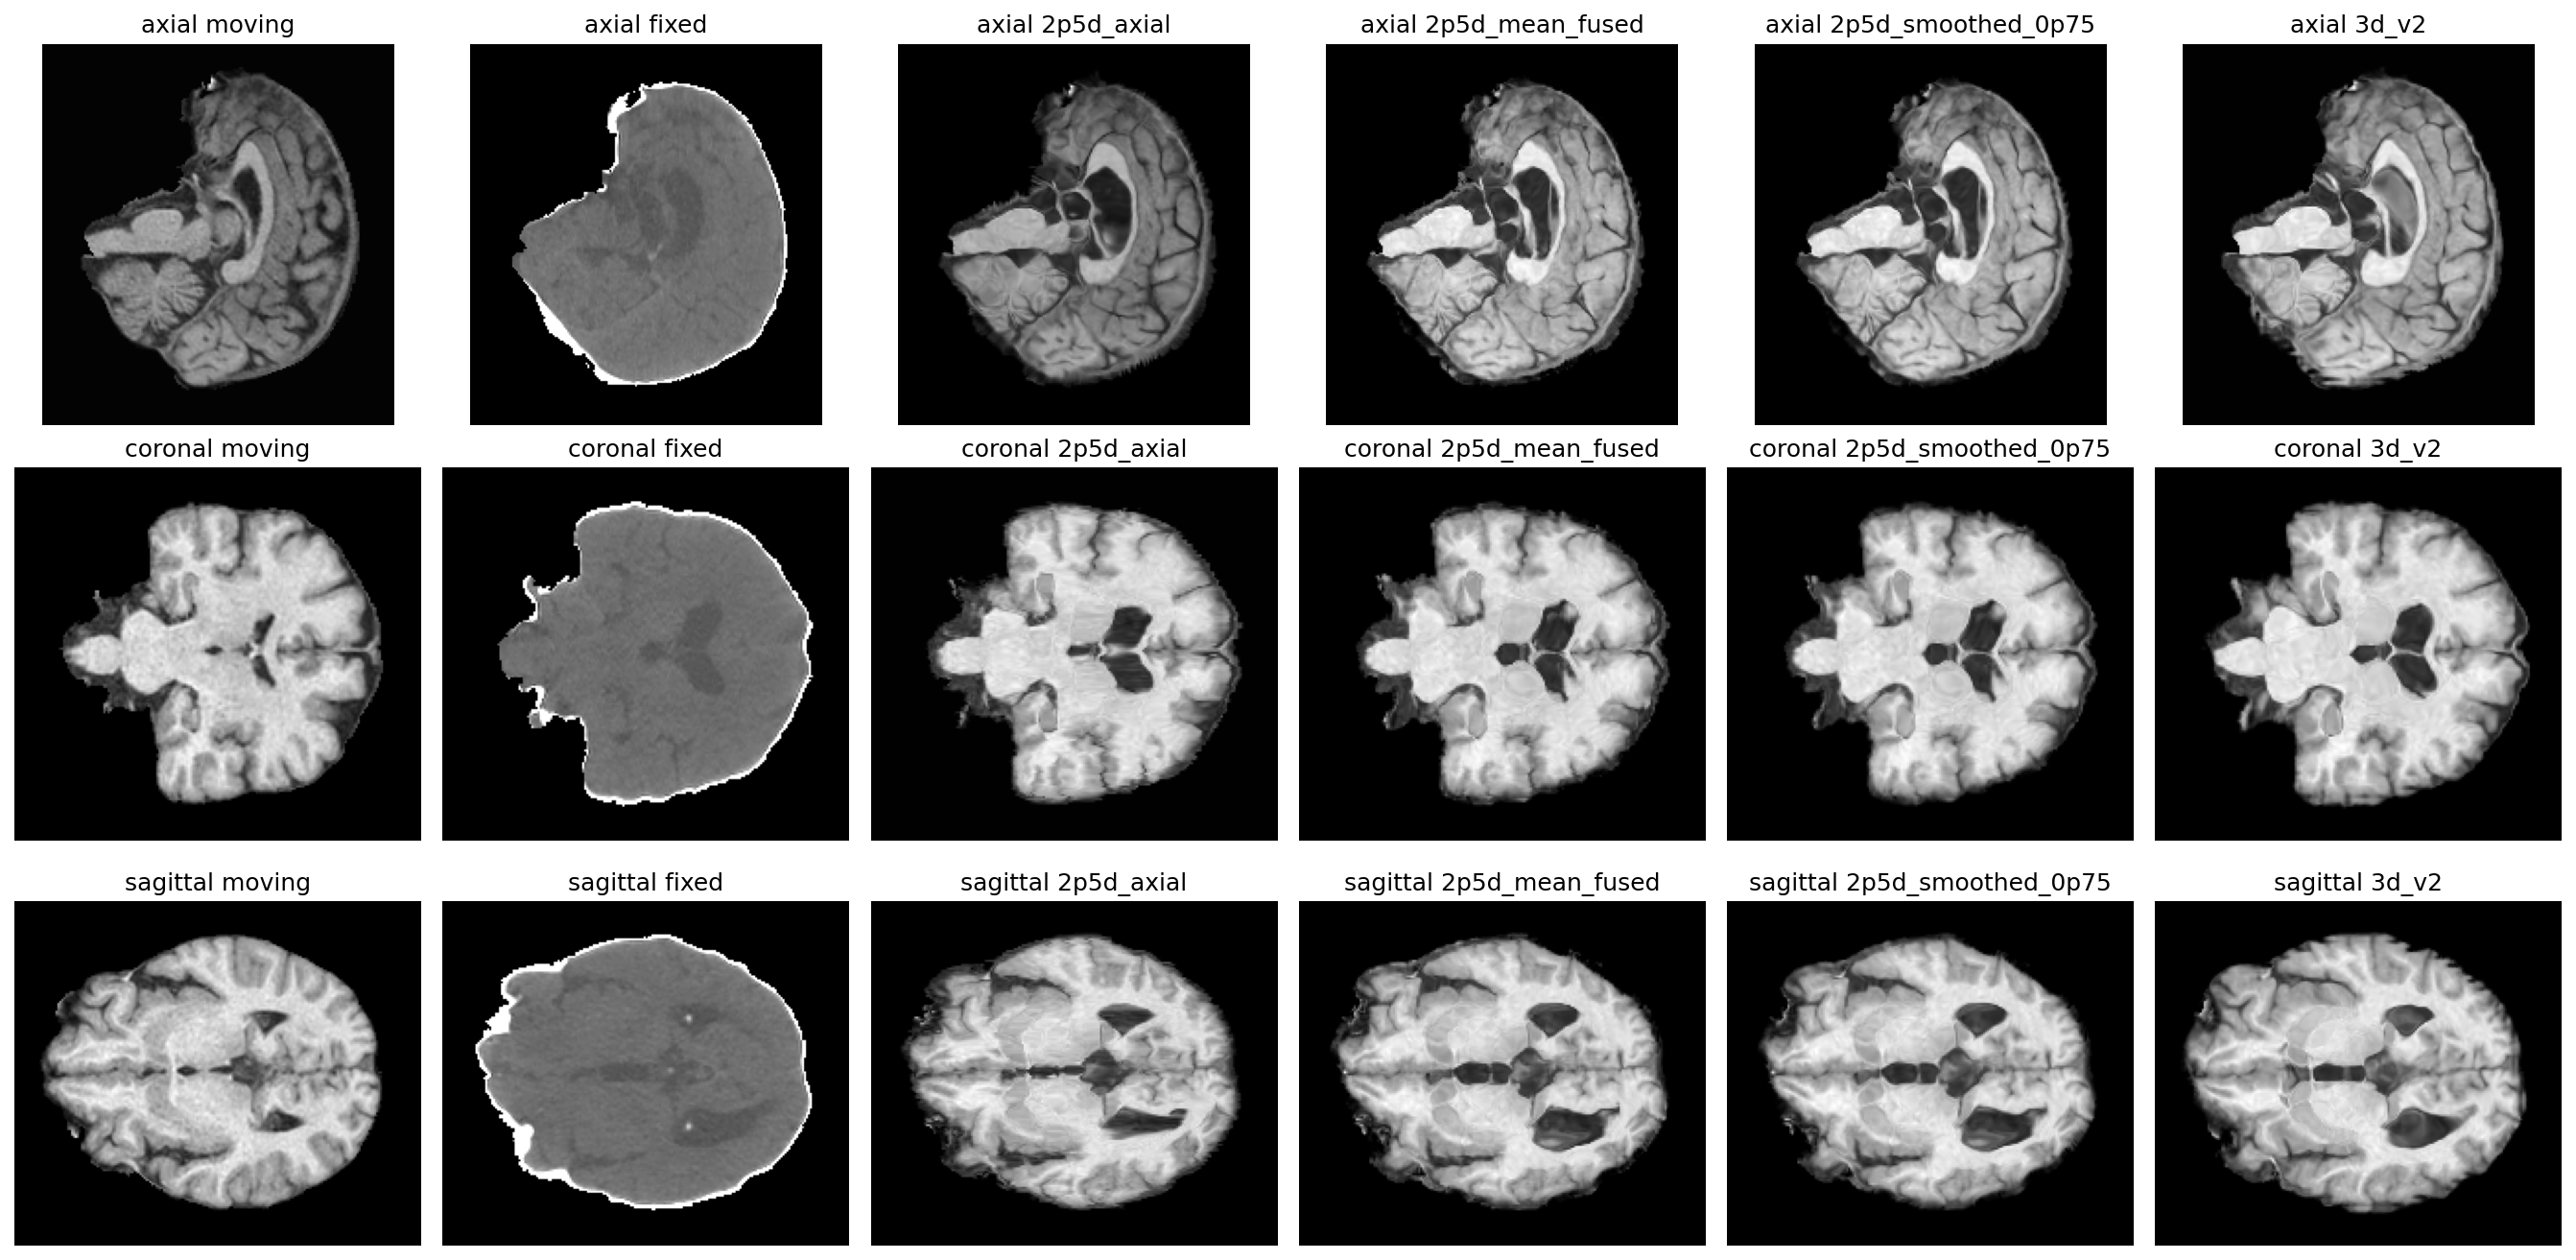

In [7]:
print((OUTPUT_ROOT / 'aggregate.json').read_text())

preview_device = 'cuda' if (OUTPUT_ROOT / 'cuda').exists() else REQUESTED_DEVICE_NAMES[0]
if benchmark_rows_by_device.get(preview_device):
    first = benchmark_rows_by_device[preview_device][0]
    pair_name = f"pair_{first['pair_index']:02d}_m{first['moving_idx']:03d}_f{first['fixed_idx']:03d}"
    display(Image(filename=str(OUTPUT_ROOT / preview_device / pair_name / 'comparison_preview.png')))



In [8]:
import csv
from datetime import datetime


def load_rows_for_device(device_name):
    if 'benchmark_rows_by_device' in globals() and device_name in benchmark_rows_by_device:
        return benchmark_rows_by_device[device_name]
    summary_path = OUTPUT_ROOT / device_name / 'summary.json'
    if not summary_path.exists():
        raise FileNotFoundError(f'Could not find {summary_path}. Run the benchmark cell first.')
    return json.loads(summary_path.read_text())


def load_available_devices():
    if 'benchmark_rows_by_device' in globals() and benchmark_rows_by_device:
        return list(benchmark_rows_by_device.keys())
    found = []
    for device_name in ['cpu', 'cuda']:
        if (OUTPUT_ROOT / device_name / 'summary.json').exists():
            found.append(device_name)
    if not found:
        raise FileNotFoundError('No per-device benchmark outputs found.')
    return found


def tensor_state_stats(path):
    state = torch.load(path, map_location='cpu')
    if isinstance(state, dict) and 'state_dict' in state and isinstance(state['state_dict'], dict):
        state = state['state_dict']
    if not isinstance(state, dict):
        raise TypeError(f'Unsupported checkpoint format for {path}')
    total_params = 0
    total_bytes = 0
    for value in state.values():
        if torch.is_tensor(value):
            total_params += value.numel()
            total_bytes += value.numel() * value.element_size()
    return {
        'checkpoint_path': str(path),
        'checkpoint_size_mb': float(path.stat().st_size / (1024 ** 2)),
        'parameter_count': int(total_params),
        'estimated_fp_tensor_mb': float(total_bytes / (1024 ** 2)),
    }


def metric_stats(values):
    arr = np.asarray(values, dtype=np.float64)
    return {
        'mean': float(arr.mean()),
        'std': float(arr.std(ddof=0)),
        'median': float(np.median(arr)),
        'min': float(arr.min()),
        'max': float(arr.max()),
    }


def paired_delta(rows, method_a, method_b, metric):
    diffs = [row[method_a][metric] - row[method_b][metric] for row in rows]
    out = metric_stats(diffs)
    out['wins_a'] = int(sum(d > 1e-9 for d in diffs))
    out['wins_b'] = int(sum(d < -1e-9 for d in diffs))
    out['ties'] = int(sum(abs(d) <= 1e-9 for d in diffs))
    return out


def device_consistency(cpu_rows, gpu_rows, method, metric):
    diffs = [gpu_rows[i][method][metric] - cpu_rows[i][method][metric] for i in range(len(cpu_rows))]
    out = metric_stats(diffs)
    out['max_abs'] = float(np.max(np.abs(np.asarray(diffs, dtype=np.float64))))
    return out


methods = ['2p5d_axial', '2p5d_mean_fused', '2p5d_smoothed_0p75', '3d_v2']
method_labels = {
    '2p5d_axial': '2.5D axial',
    '2p5d_mean_fused': '2.5D mean fused',
    '2p5d_smoothed_0p75': '2.5D smoothed 0.75',
    '3d_v2': '3D V2',
}

available_devices = load_available_devices()
model_info = {
    '2p5d_v2': tensor_state_stats(Path(MODEL_2P5D_PATH)),
    '3d_v2': tensor_state_stats(Path(MODEL_3D_PATH)),
}

benchmark = {
    'generated_at': datetime.utcnow().isoformat() + 'Z',
    'devices': {},
    'model_info': model_info,
}

csv_rows = []
for device_name in available_devices:
    rows = load_rows_for_device(device_name)
    source_path = OUTPUT_ROOT / device_name / 'source.txt'
    device_block = {
        'device': device_name,
        'source': source_path.read_text().strip() if source_path.exists() else 'generated from current notebook execution',
        'pair_count': len(rows),
        'pairs': [
            {
                'pair_index': int(row['pair_index']),
                'moving_idx': int(row['moving_idx']),
                'fixed_idx': int(row['fixed_idx']),
            }
            for row in rows
        ],
        'methods': {},
        'win_counts': {
            'dice_after': {m: 0 for m in methods},
            'mi_after': {m: 0 for m in methods},
            'runtime_fastest': {m: 0 for m in methods},
        },
        'head_to_head': {},
    }

    for method in methods:
        method_rows = [row[method] for row in rows]
        dice_before = [m['dice_before'] for m in method_rows]
        dice_after = [m['dice_after'] for m in method_rows]
        dice_gain = [m['dice_after'] - m['dice_before'] for m in method_rows]
        mi_before = [m['mi_before'] for m in method_rows]
        mi_after = [m['mi_after'] for m in method_rows]
        mi_gain = [m['mi_after'] - m['mi_before'] for m in method_rows]
        ssim_deformed_fixed = [m['ssim_deformed_fixed'] for m in method_rows]
        ssim_deformed_moving = [m['ssim_deformed_moving'] for m in method_rows]
        flow_std = [m['flow_std'] for m in method_rows]
        model_ms = [m['model_inference_ms'] for m in method_rows]
        post_ms = [m['postprocess_ms'] for m in method_rows]
        total_ms = [m['total_runtime_ms'] for m in method_rows]
        peak_values = [m.get('peak_memory_mb') for m in method_rows if m.get('peak_memory_mb') is not None]
        method_block = {
            'label': method_labels[method],
            'dice_before': metric_stats(dice_before),
            'dice_after': metric_stats(dice_after),
            'dice_gain': metric_stats(dice_gain),
            'dice_error_after': metric_stats([1.0 - v for v in dice_after]),
            'mi_before': metric_stats(mi_before),
            'mi_after': metric_stats(mi_after),
            'mi_gain': metric_stats(mi_gain),
            'ssim_deformed_fixed': metric_stats(ssim_deformed_fixed),
            'ssim_deformed_moving': metric_stats(ssim_deformed_moving),
            'flow_std': metric_stats(flow_std),
            'model_inference_ms': metric_stats(model_ms),
            'postprocess_ms': metric_stats(post_ms),
            'total_runtime_ms': metric_stats(total_ms),
        }
        if peak_values:
            method_block['peak_memory_mb'] = metric_stats(peak_values)
        device_block['methods'][method] = method_block

    for row in rows:
        best_dice_method = max(methods, key=lambda m: row[m]['dice_after'])
        best_mi_method = max(methods, key=lambda m: row[m]['mi_after'])
        fastest_method = min(methods, key=lambda m: row[m]['total_runtime_ms'])
        device_block['win_counts']['dice_after'][best_dice_method] += 1
        device_block['win_counts']['mi_after'][best_mi_method] += 1
        device_block['win_counts']['runtime_fastest'][fastest_method] += 1

        for method in methods:
            entry = row[method]
            csv_rows.append({
                'device': device_name,
                'pair_index': row['pair_index'],
                'moving_idx': row['moving_idx'],
                'fixed_idx': row['fixed_idx'],
                'method': method,
                'dice_before': entry['dice_before'],
                'dice_after': entry['dice_after'],
                'dice_gain': entry['dice_after'] - entry['dice_before'],
                'mi_before': entry['mi_before'],
                'mi_after': entry['mi_after'],
                'mi_gain': entry['mi_after'] - entry['mi_before'],
                'ssim_deformed_fixed': entry['ssim_deformed_fixed'],
                'ssim_deformed_moving': entry['ssim_deformed_moving'],
                'flow_std': entry['flow_std'],
                'model_inference_ms': entry['model_inference_ms'],
                'postprocess_ms': entry['postprocess_ms'],
                'total_runtime_ms': entry['total_runtime_ms'],
                'peak_memory_mb': entry.get('peak_memory_mb'),
            })

    device_block['head_to_head']['2p5d_mean_fused_vs_3d_v2'] = {
        'dice_after': paired_delta(rows, '2p5d_mean_fused', '3d_v2', 'dice_after'),
        'mi_after': paired_delta(rows, '2p5d_mean_fused', '3d_v2', 'mi_after'),
        'ssim_deformed_fixed': paired_delta(rows, '2p5d_mean_fused', '3d_v2', 'ssim_deformed_fixed'),
        'ssim_deformed_moving': paired_delta(rows, '2p5d_mean_fused', '3d_v2', 'ssim_deformed_moving'),
        'total_runtime_ms': paired_delta(rows, '2p5d_mean_fused', '3d_v2', 'total_runtime_ms'),
    }
    device_block['head_to_head']['2p5d_smoothed_0p75_vs_2p5d_mean_fused'] = {
        'dice_after': paired_delta(rows, '2p5d_smoothed_0p75', '2p5d_mean_fused', 'dice_after'),
        'mi_after': paired_delta(rows, '2p5d_smoothed_0p75', '2p5d_mean_fused', 'mi_after'),
        'ssim_deformed_fixed': paired_delta(rows, '2p5d_smoothed_0p75', '2p5d_mean_fused', 'ssim_deformed_fixed'),
        'ssim_deformed_moving': paired_delta(rows, '2p5d_smoothed_0p75', '2p5d_mean_fused', 'ssim_deformed_moving'),
        'total_runtime_ms': paired_delta(rows, '2p5d_smoothed_0p75', '2p5d_mean_fused', 'total_runtime_ms'),
    }
    device_block['head_to_head']['2p5d_axial_vs_3d_v2'] = {
        'dice_after': paired_delta(rows, '2p5d_axial', '3d_v2', 'dice_after'),
        'mi_after': paired_delta(rows, '2p5d_axial', '3d_v2', 'mi_after'),
        'ssim_deformed_fixed': paired_delta(rows, '2p5d_axial', '3d_v2', 'ssim_deformed_fixed'),
        'ssim_deformed_moving': paired_delta(rows, '2p5d_axial', '3d_v2', 'ssim_deformed_moving'),
        'total_runtime_ms': paired_delta(rows, '2p5d_axial', '3d_v2', 'total_runtime_ms'),
    }
    benchmark['devices'][device_name] = device_block

if 'cpu' in benchmark['devices'] and 'cuda' in benchmark['devices']:
    cpu_rows = load_rows_for_device('cpu')
    gpu_rows = load_rows_for_device('cuda')
    speedup = {}
    consistency = {}
    for method in methods:
        cpu_method = benchmark['devices']['cpu']['methods'][method]
        gpu_method = benchmark['devices']['cuda']['methods'][method]
        speedup[method] = {
            'label': method_labels[method],
            'model_inference_x': float(cpu_method['model_inference_ms']['mean'] / gpu_method['model_inference_ms']['mean']),
            'postprocess_x': float(cpu_method['postprocess_ms']['mean'] / gpu_method['postprocess_ms']['mean']),
            'total_runtime_x': float(cpu_method['total_runtime_ms']['mean'] / gpu_method['total_runtime_ms']['mean']),
        }
        consistency[method] = {
            'label': method_labels[method],
            'dice_after_gpu_minus_cpu': device_consistency(cpu_rows, gpu_rows, method, 'dice_after'),
            'mi_after_gpu_minus_cpu': device_consistency(cpu_rows, gpu_rows, method, 'mi_after'),
            'ssim_deformed_fixed_gpu_minus_cpu': device_consistency(cpu_rows, gpu_rows, method, 'ssim_deformed_fixed'),
            'ssim_deformed_moving_gpu_minus_cpu': device_consistency(cpu_rows, gpu_rows, method, 'ssim_deformed_moving'),
            'flow_std_gpu_minus_cpu': device_consistency(cpu_rows, gpu_rows, method, 'flow_std'),
        }
    benchmark['cpu_vs_gpu'] = {
        'speedup': speedup,
        'consistency': consistency,
    }

summary_path = OUTPUT_ROOT / 'benchmark_summary.json'
summary_path.write_text(json.dumps(benchmark, indent=2))

csv_path = OUTPUT_ROOT / 'per_pair_metrics.csv'
fieldnames = [
    'device', 'pair_index', 'moving_idx', 'fixed_idx', 'method',
    'dice_before', 'dice_after', 'dice_gain',
    'mi_before', 'mi_after', 'mi_gain',
    'ssim_deformed_fixed', 'ssim_deformed_moving',
    'flow_std', 'model_inference_ms', 'postprocess_ms', 'total_runtime_ms', 'peak_memory_mb'
]
with csv_path.open('w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(csv_rows)

lines = []
lines.append('# 2.5D Fusion vs 3D V2 Test Benchmark')
lines.append('')
lines.append(f"Generated: {benchmark['generated_at']}")
lines.append(f"Devices: {', '.join(available_devices)}")
lines.append('')
lines.append('## Model Size')
lines.append('')
lines.append('| Model | Params | Checkpoint MB | Estimated FP Tensor MB |')
lines.append('| --- | ---: | ---: | ---: |')
lines.append(f"| 2.5D V2 | {model_info['2p5d_v2']['parameter_count']:,} | {model_info['2p5d_v2']['checkpoint_size_mb']:.2f} | {model_info['2p5d_v2']['estimated_fp_tensor_mb']:.2f} |")
lines.append(f"| 3D V2 | {model_info['3d_v2']['parameter_count']:,} | {model_info['3d_v2']['checkpoint_size_mb']:.2f} | {model_info['3d_v2']['estimated_fp_tensor_mb']:.2f} |")
lines.append('')

for device_name in available_devices:
    block = benchmark['devices'][device_name]
    lines.append(f'## Device: {device_name}')
    lines.append('')
    lines.append(f"Source: {block['source']}")
    lines.append('')
    lines.append('| Method | Dice After | Dice Gain | Dice Error | MI After | MI Gain | SSIM(def,fixed) | SSIM(def,moving) | Model ms | Post ms | Total ms | Peak Mem MB |')
    lines.append('| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |')
    for method in methods:
        m = block['methods'][method]
        peak = m.get('peak_memory_mb', {}).get('mean') if 'peak_memory_mb' in m else None
        peak_str = f'{peak:.1f}' if peak is not None else 'n/a'
        lines.append(
            f"| {m['label']} | {m['dice_after']['mean']:.4f} +/- {m['dice_after']['std']:.4f} | "
            f"{m['dice_gain']['mean']:.4f} | {m['dice_error_after']['mean']:.4f} | "
            f"{m['mi_after']['mean']:.4f} +/- {m['mi_after']['std']:.4f} | {m['mi_gain']['mean']:.4f} | "
            f"{m['ssim_deformed_fixed']['mean']:.4f} +/- {m['ssim_deformed_fixed']['std']:.4f} | "
            f"{m['ssim_deformed_moving']['mean']:.4f} +/- {m['ssim_deformed_moving']['std']:.4f} | "
            f"{m['model_inference_ms']['mean']:.1f} | {m['postprocess_ms']['mean']:.1f} | {m['total_runtime_ms']['mean']:.1f} | {peak_str} |"
        )
    lines.append('')
    lines.append('Win counts:')
    lines.append('')
    lines.append('| Category | 2.5D axial | 2.5D mean fused | 2.5D smoothed 0.75 | 3D V2 |')
    lines.append('| --- | ---: | ---: | ---: | ---: |')
    lines.append(
        f"| Best Dice | {block['win_counts']['dice_after']['2p5d_axial']} | {block['win_counts']['dice_after']['2p5d_mean_fused']} | {block['win_counts']['dice_after']['2p5d_smoothed_0p75']} | {block['win_counts']['dice_after']['3d_v2']} |"
    )
    lines.append(
        f"| Best MI | {block['win_counts']['mi_after']['2p5d_axial']} | {block['win_counts']['mi_after']['2p5d_mean_fused']} | {block['win_counts']['mi_after']['2p5d_smoothed_0p75']} | {block['win_counts']['mi_after']['3d_v2']} |"
    )
    lines.append(
        f"| Fastest | {block['win_counts']['runtime_fastest']['2p5d_axial']} | {block['win_counts']['runtime_fastest']['2p5d_mean_fused']} | {block['win_counts']['runtime_fastest']['2p5d_smoothed_0p75']} | {block['win_counts']['runtime_fastest']['3d_v2']} |"
    )
    lines.append('')
    hh = block['head_to_head']['2p5d_mean_fused_vs_3d_v2']
    lines.append(
        f"2.5D mean fused vs 3D V2: Dice delta {hh['dice_after']['mean']:+.4f}, MI delta {hh['mi_after']['mean']:+.4f}, "
        f"SSIM(def,fixed) delta {hh['ssim_deformed_fixed']['mean']:+.4f}, SSIM(def,moving) delta {hh['ssim_deformed_moving']['mean']:+.4f}, "
        f"total runtime delta {hh['total_runtime_ms']['mean']:+.1f} ms."
    )
    lines.append('')

if 'cpu_vs_gpu' in benchmark:
    lines.append('## CPU vs GPU')
    lines.append('')
    lines.append('| Method | Model Speedup x | Post Speedup x | Total Speedup x | Dice Drift | MI Drift | SSIM(def,fixed) Drift | SSIM(def,moving) Drift |')
    lines.append('| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |')
    for method in methods:
        speed = benchmark['cpu_vs_gpu']['speedup'][method]
        cons = benchmark['cpu_vs_gpu']['consistency'][method]
        lines.append(
            f"| {method_labels[method]} | {speed['model_inference_x']:.2f} | {speed['postprocess_x']:.2f} | {speed['total_runtime_x']:.2f} | "
            f"{cons['dice_after_gpu_minus_cpu']['mean']:+.6f} | {cons['mi_after_gpu_minus_cpu']['mean']:+.6f} | "
            f"{cons['ssim_deformed_fixed_gpu_minus_cpu']['mean']:+.6f} | {cons['ssim_deformed_moving_gpu_minus_cpu']['mean']:+.6f} |"
        )
    lines.append('')
    lines.append('The drift columns are GPU minus CPU. Small values indicate numerically stable evaluation across devices.')
    lines.append('')

lines.append('## Interpretation')
lines.append('')
if 'cpu' in benchmark['devices']:
    cpu_methods = benchmark['devices']['cpu']['methods']
    best_cpu_dice = max(methods, key=lambda m: cpu_methods[m]['dice_after']['mean'])
    best_cpu_mi = max(methods, key=lambda m: cpu_methods[m]['mi_after']['mean'])
    fastest_cpu = min(methods, key=lambda m: cpu_methods[m]['total_runtime_ms']['mean'])
    lines.append(f"On CPU, best Dice is {method_labels[best_cpu_dice]} and best MI is {method_labels[best_cpu_mi]}. Fastest is {method_labels[fastest_cpu]}.")
if 'cuda' in benchmark['devices']:
    gpu_methods = benchmark['devices']['cuda']['methods']
    best_gpu_dice = max(methods, key=lambda m: gpu_methods[m]['dice_after']['mean'])
    best_gpu_mi = max(methods, key=lambda m: gpu_methods[m]['mi_after']['mean'])
    fastest_gpu = min(methods, key=lambda m: gpu_methods[m]['total_runtime_ms']['mean'])
    lines.append(f"On GPU, best Dice is {method_labels[best_gpu_dice]} and best MI is {method_labels[best_gpu_mi]}. Fastest is {method_labels[fastest_gpu]}.")
lines.append('2.5D mean fusion remains the strongest overlap method overall. 3D V2 remains competitive while using a single volumetric pass. 2.5D axial is the simplest and fastest single-view baseline.')
lines.append('')
lines.append('## Outputs')
lines.append('')
for device_name in available_devices:
    lines.append(f"- Per-device outputs: `{OUTPUT_ROOT / device_name}`")
lines.append(f"- Combined benchmark JSON: `{summary_path}`")
lines.append(f"- Combined CSV: `{csv_path}`")

report_path = OUTPUT_ROOT / 'benchmark_summary.txt'
report_path.write_text('\n'.join(lines) + '\n')
print(summary_path.read_text())
print('\n--- report ---\n')
print(report_path.read_text())





{
  "generated_at": "2026-04-13T16:23:28.848339Z",
  "devices": {
    "cpu": {
      "device": "cpu",
      "source": "generated from current notebook execution",
      "pair_count": 9,
      "pairs": [
        {
          "pair_index": 0,
          "moving_idx": 2,
          "fixed_idx": 17
        },
        {
          "pair_index": 1,
          "moving_idx": 1,
          "fixed_idx": 12
        },
        {
          "pair_index": 2,
          "moving_idx": 6,
          "fixed_idx": 0
        },
        {
          "pair_index": 3,
          "moving_idx": 16,
          "fixed_idx": 4
        },
        {
          "pair_index": 4,
          "moving_idx": 14,
          "fixed_idx": 8
        },
        {
          "pair_index": 5,
          "moving_idx": 5,
          "fixed_idx": 9
        },
        {
          "pair_index": 6,
          "moving_idx": 13,
          "fixed_idx": 11
        },
        {
          "pair_index": 7,
          "moving_idx": 7,
          "fixed_idx": 10
 

In [9]:
print((OUTPUT_ROOT / 'benchmark_summary.json').read_text())
print('\n--- report ---\n')
print((OUTPUT_ROOT / 'benchmark_summary.txt').read_text())



{
  "generated_at": "2026-04-13T16:23:28.848339Z",
  "devices": {
    "cpu": {
      "device": "cpu",
      "source": "generated from current notebook execution",
      "pair_count": 9,
      "pairs": [
        {
          "pair_index": 0,
          "moving_idx": 2,
          "fixed_idx": 17
        },
        {
          "pair_index": 1,
          "moving_idx": 1,
          "fixed_idx": 12
        },
        {
          "pair_index": 2,
          "moving_idx": 6,
          "fixed_idx": 0
        },
        {
          "pair_index": 3,
          "moving_idx": 16,
          "fixed_idx": 4
        },
        {
          "pair_index": 4,
          "moving_idx": 14,
          "fixed_idx": 8
        },
        {
          "pair_index": 5,
          "moving_idx": 5,
          "fixed_idx": 9
        },
        {
          "pair_index": 6,
          "moving_idx": 13,
          "fixed_idx": 11
        },
        {
          "pair_index": 7,
          "moving_idx": 7,
          "fixed_idx": 10
 